# Exercise 8.2d solution

We copy our code from Exercise 8.2a and add the two new currents.


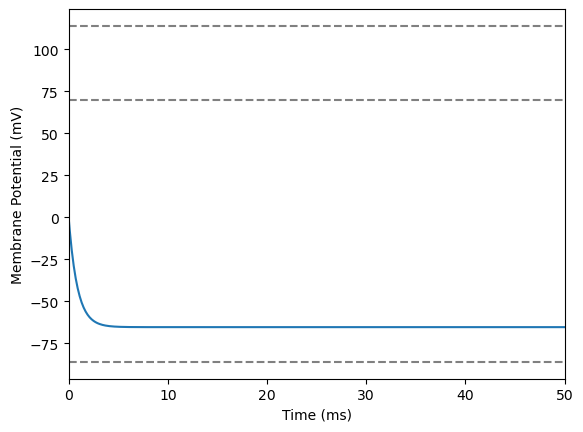

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp


# Define the ODE
def rhs(t, V, Cm, g_Na, g_K, g_Ca, E_Na, E_K, E_Ca):
    dV_dt = -(g_Na * (V - E_Na) + g_K * (V - E_K) + g_Ca * (V - E_Ca)) / Cm
    return dV_dt


# Define the parameters and initial condition
T = (0, 50)
Cm = 0.05  # nF
g_Na = 0.005  # µS
g_K = 0.05  # µS
g_Ca = 0.002  # µS

# Approximate Nernst potentials from Ex 8.1
E_Na = 70.0  # mV
E_K = -86.0  # mV
E_Ca = 114.0  # mV

params = (Cm, g_Na, g_K, g_Ca, E_Na, E_K, E_Ca)
y0 = (0,)  # mV (Starting at 0 mV this time)

# Solve the ODE
solution = solve_ivp(rhs, T, y0, args=params, max_step=0.1)

t = solution.t
(V,) = solution.y

plt.plot(t, V)
plt.axhline(E_Na, linestyle="--", color="grey")
plt.axhline(E_Ca, linestyle="--", color="grey")
plt.axhline(E_K, linestyle="--", color="grey")
plt.xlabel("Time (ms)")
plt.ylabel("Membrane Potential (mV)")
plt.xlim(0, 50)
plt.show()